# U2: Reducción de la dimensionalidad
## | FCEIA - Tec. Universitaria en Inteligencia Artificial - Minería de Datos


# Repaso

## ✅ Lista de chequeo
Ejemplo de algunos pasos iniciales a tener en cuenta en un proyecto de *Minería de Datos*:

1. Definición del objetivo
2. Adquisición de datos
3. Examinar estructura
4. Separación del conjunto de prueba
5. Análisis exploratorio
6. Preparación de los datos:
    - Limpieza
    - Escalado
    - Discretización
7. Aplicación del modelo

# 1. 🎯 Objetivo
Llevar a la práctica los conceptos de EDA y PCA.

# 2. 📂 Adquisición de datos

## Descripción

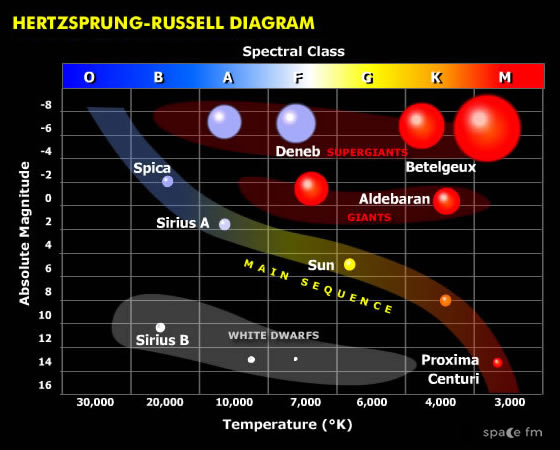

El dataset a utilizar es "Star dataset to predict star type", pueden encontrarlo haciendo click [aquí](https://www.kaggle.com/datasets/deepu1109/star-dataset) .

Este dataset contiene multiples características de estrellas.

Estas son:

- **Absolute Temperature (K)** temperatura absoluta de la superficie de una estrella.
- **Relative Luminosity (L/Lo)** Luminosidad relativa de una estrella calculada con respecto al Sol.
- **Relative Radius (R/Ro)** Radio relativo de una estrella calculado respecto al Sol.
- **Absolute Magnitude (Mv)** Magnitud absoluta visual de una estrella.
- **Star Color (white,Red,Blue,Yellow,yellow-orange etc)** color de la estrella calculado a partir de un análisis espectral.
- **Spectral Class (O,B,A,F,G,K,M)** clase espectral de una estrella.
- **Star Type (Red Dwarf, Brown Dwarf, White Dwarf, Main Sequence , SuperGiants, HyperGiants)** Tipo de estrella (*variable objetivo*).

  |_Brown Dwarf -> Star Type = 0

  |_Red Dwarf -> Star Type = 1

  |_White Dwarf-> Star Type = 2

  |_Main Sequence -> Star Type = 3

  |_Supergiant -> Star Type = 4

  |_Hypergiant -> Star Type = 5

# 📦 Configuración

## Librerías

In [ ]:
# Manejo de datos
import os
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches
import plotly.express as px
import seaborn as sns

# Flujo de datos
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, Isomap, TSNE

## Datos

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("deepu1109/star-dataset")
print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 3.16k/3.16k [00:00<00:00, 4.07MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/deepu1109/star-dataset/versions/1
['6 class csv.csv']


## Funciones

In [ ]:
def plot_correlation_heatmap(corr, title):
    ax = sns.heatmap(
        corr,
        vmin=-1, vmax=1, center=0,
        cmap=sns.diverging_palette(20, 220, n=200),
        square=True,
        annot = True,
        annot_kws = {'size': 6})
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment='right')
    plt.title(title)
    plt.show()

# 3. 🔎 Estructura y Análisis exploratorio


El análisis y limpieza de un dataset es importante, ya que determina en gran medida el funcionamiento posterior de cualquier algoritmo / modelo que deseemos utilizar, como así también es fundamental para comprender el comportamiento de los mismos y del fenómeno a analizar.

Un trabajo de análisis podría responder a las siguientes preguntas:
1. Estructura:
    - ¿Cuántos muestras (filas) tengo?
    - ¿Cuantas variables (columnas) observo?
    - ¿Tiene nulos mi dataset?
    - ¿Hay variables continuas y/o categóricas?¿Cuales son y en que cantidad?
2. Variación dentro de las variables:
    - ¿Cómo son las medidas (mediana, media, cuartiles) de las variables?
    - ¿Cuál es la distribución de las variables continuas y categóricas?
    - ¿Qué comportamiento observo a priori?
3. Variación entre variables:
    - ¿Cuál es la correlación entre las variables?¿Y con la variable objetivo?
    - ¿Que tipo de correlación existe?
4. Limpieza:
    - ¿Hay errores en los datos?
    - ¿Cómo trato a los valores nulos? ¿Cómo afecta a los datos mi tratamiento?
    - ¿Tiene atípicos? ¿Cómo los trato? ¿Cómo afecta a los datos mi tratamiento?

In [ ]:
df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))

## ¿Cuantas variables (columnas) observo?

In [ ]:
df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


## ¿Cuántas muestras tengo?

In [ ]:
len(df)

240

 ## ¿Cómo son las medidas (mediana, media, cuartiles) de las variables?

In [ ]:
df.describe()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


Como star_type refiere a una categoría, para evitar confusiones y errores en los tratamientos de datos, la seteamos a categórica.

In [ ]:
df['Star type'] = df['Star type'].astype('object')

## ¿Qué comportamientos observo apriori?

**Temperatura (K)**

- Media: 10,497 K | Mediana: 5,776 K.

- Rango amplio: 1,939 K – 40,000 K.

- Desviación estándar elevada (9,552 K), lo que indica alta dispersión.

- **La media es considerablemente mayor que la mediana, lo que sugiere asimetría hacia valores altos (presencia de estrellas muy calientes que elevan el promedio).**

**Luminosidad (L/Lo)**

- Media: 107,188 | Mediana: 0.0705.

- Rango extremadamente amplio: 0.00008 – 849,420.

- Desviación estándar muy alta (179,432).

- **Fuerte asimetría positiva: pocos valores muy grandes influyen notablemente en la media.**

**Radio (R/Ro)**

- Media: 237 | Mediana: 0.76.

- Rango: 0.0084 – 1,948.5.

- Alta variabilidad (std = 517.16).

**Distribución claramente sesgada a la derecha, con algunas estrellas de gran tamaño que aumentan el promedio.**

**Magnitud Absoluta (Mv)**

- Media: 4.38 | Mediana: 8.313.

- Rango amplio: -11.92 a 20.06.

- Desviación estándar de 10.53, indicando heterogeneidad.

💡 La Magnitud Absoluta es logarítmica y mide el brillo de una estrella respecto de una referencia (Vega). Valores negativos corresponden a estrellas brillantes, mientras que valores altos corresponden a estrellas menos luminosas.

SIEMPRE es mejor una ayuda visual.

In [ ]:
dict_star_categories = {
  0:"Brown Dwarf",

  1:"Red Dwarf",

  2:"White Dwarf",

  3:"Main Sequence",

  4:"Supergiant",

  5:"Hypergiant",
}
df['Star type category'] = df['Star type'].map(dict_star_categories)

In [ ]:
df['Star type category'].value_counts()

,count
Star type category,
Brown Dwarf,40
Red Dwarf,40
White Dwarf,40
Main Sequence,40
Supergiant,40
Hypergiant,40


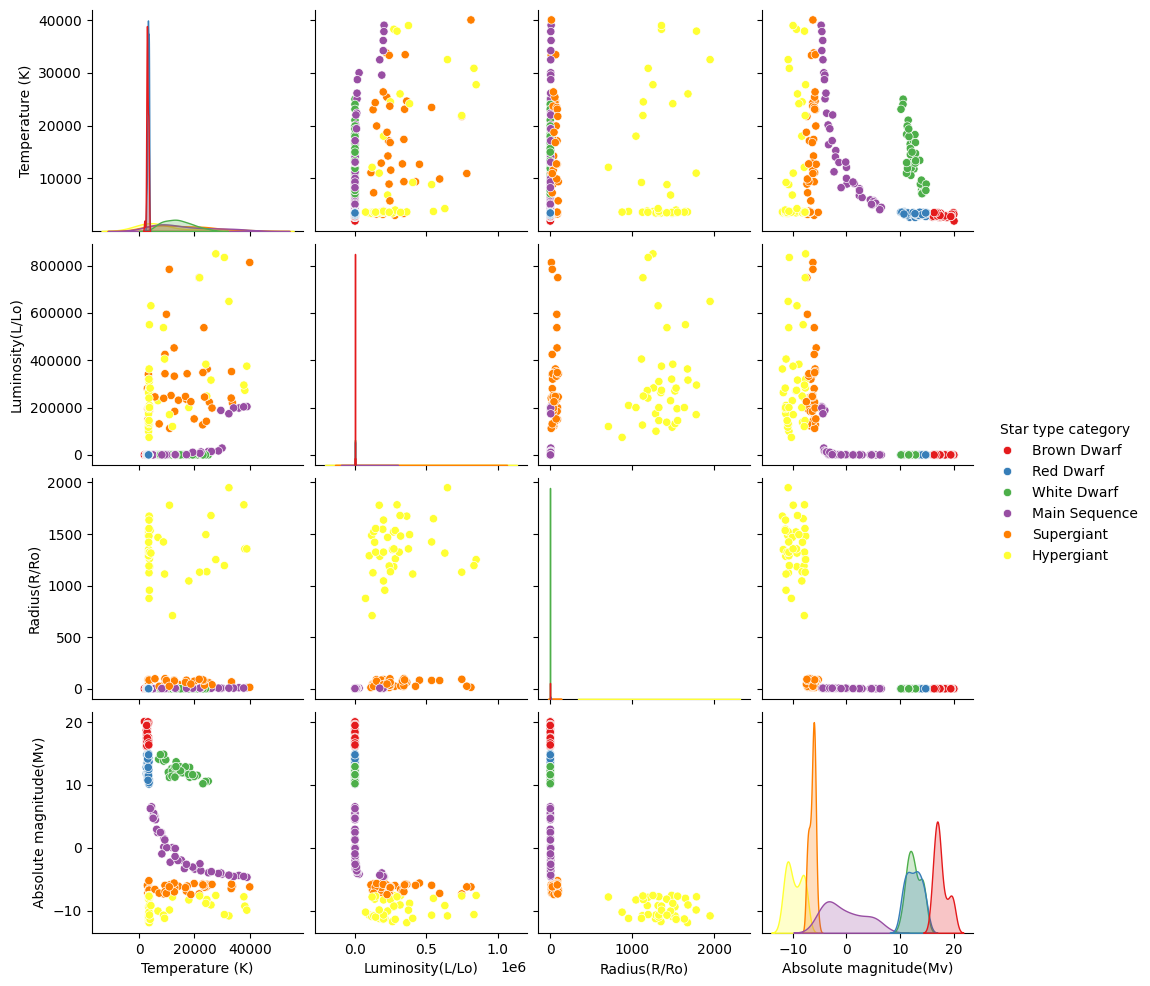

In [ ]:
sns.pairplot(df.drop('Star type', axis = 1), hue = 'Star type category', palette='Set1', diag_kind='kde')

## **¿Cuál es la distribución de las variables categóricas?**

In [ ]:
cat_columns = list(df.select_dtypes(include=['object']).columns)
cat_columns
for col in cat_columns:
  df[col] = df[col].astype('object')

In [ ]:
for col in cat_columns:
  print(f"Descripcion de la columna {col}")
  print(df[col].value_counts(dropna = 'False').sort_index())


Descripcion de la columna Star type
Star type
0    40
1    40
2    40
3    40
4    40
5    40
Name: count, dtype: int64
Descripcion de la columna Star color
Star color
Blue                   55
Blue                    1
Blue White             10
Blue white              3
Blue white              1
Blue-White              1
Blue-white             26
Orange                  2
Orange-Red              1
Pale yellow orange      1
Red                   112
White                   7
White-Yellow            1
Whitish                 2
Yellowish               1
Yellowish White         3
white                   3
yellow-white            8
yellowish               2
Name: count, dtype: int64
Descripcion de la columna Spectral Class
Spectral Class
A     19
B     46
F     17
G      1
K      6
M    111
O     40
Name: count, dtype: int64
Descripcion de la columna Star type category
Star type category
Brown Dwarf      40
Hypergiant       40
Main Sequence    40
Red Dwarf        40
Supergiant       40
Whi

Se observa que:

**Star color**
- Hay varios nombres que refieren a una misma estrella: errores de tipeo, caracteres extra, etc.

**Spectral Class**
- La clase predominante es la clase espectral "M", casi triplicando los valores de la segunda y tercera clase dominante.
- Las clases que menos frecuencia presentan en el dataset son K y G, teniendo 6 y 1 aparicion respectivamente.

**Star type**
- Está perfectamente balanceada.

## **¿Hay errores en los datos? ¿Cómo los corrijo?**

Se observaron errores en Star color. Se tratará este error normalizando dichos nombres.

Red    
               
Blue                   
Blue-white: Blue-white, Blue White, Blue white, Blue white, Blue-White

yellow-white: Yellowish White, White-Yellow, yellowish

White: white, Whitish

Orange: Pale yellow orange, Orange-Red              

Se mantiene como regla, para aquellas estrellas con dos palabras Palabra1-palabra2.

In [ ]:
## Quitamos espacion innecesarios en el datasaet
df["Star color"] = df["Star color"].str.strip()

In [ ]:
# Diccionario de map (es importante SIEMPRE incluir en los valores, el valor de la clave (que queremos que quede))
dict_colors = {
    'Red': 'Red',
    'Blue': 'Blue',
    'Blue-white': ['Blue-white', 'Blue-white', 'Blue White', 'Blue white', 'Blue white', 'Blue-White'],
    'Yellow-white': ['yellow-white', 'Yellowish White', 'White-Yellow', 'yellowish','Yellowish'],
    'White': ['white', 'Whitish','White'],
    'Orange': ['Pale yellow orange', 'Orange-Red','Orange']
}

#Formateo apto para .map
color_map = {}

for key, value in dict_colors.items():
    if isinstance(value, list):
        for v in value:
            color_map[v] = key
    else:
        color_map[value] = key


In [ ]:
# Chequeamos que no haya quedado ningun valor sin mapear
set(df["Star color"]) - set(color_map.keys())

set()

In [ ]:
# Aplicamos el map
df['Star color'] = df['Star color'].map(color_map)

In [ ]:
df['Star color'].value_counts()

,count
Star color,
Red,112
Blue,56
Blue-white,41
Yellow-white,15
White,12
Orange,4


Una vez hecho el cambio, debemos analizar la variable nuevamente.

**Distribución general**
La variable Star color presenta una distribución claramente desigual entre categorías, con predominio marcado de algunos colores sobre otros.

- **Red (112 observaciones)**
Es la categoría más frecuente, representando casi la mitad del total (≈47%). Esto indica una alta presencia de estrellas rojas en la muestra.

- **Blue (56 observaciones)**
Segunda categoría en frecuencia (≈23%). Su proporción es aproximadamente la mitad de las estrellas rojas.

El resto de las estrellas aparece con menor frecuencia.

**Estamos frente a una categoría DESBALANCEADA**

## ¿Tiene atípicos? ¿Cómo los trato? ¿Cómo afectó a los datos mi tratamiento?

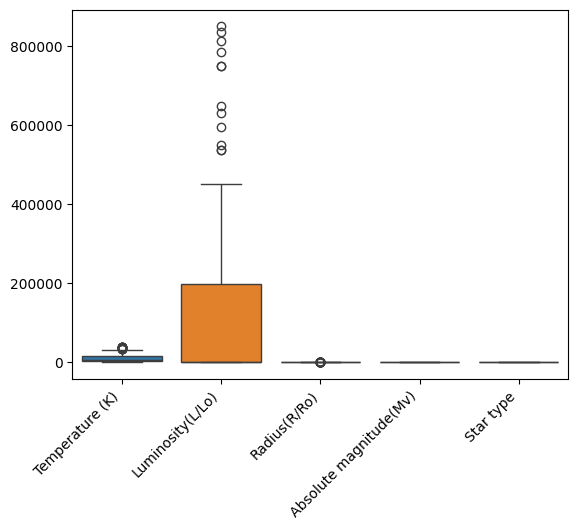

In [ ]:
sns.boxplot(df)
plt.xticks(rotation=45, ha="right")
plt.show()

Como era de esperar, Luminosity(L/Lo), que es la que más desviación estándar tenía, presenta atípicos.

In [ ]:
## Contar cantidad de atípicos por columna
for col in df.columns:
  if col not in cat_columns:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Cantidad de atípicos en {col}: {len(outliers) } | {len(outliers)/len(df) * 100}")


Cantidad de atípicos en Temperature (K): 11 | 4.583333333333333
Cantidad de atípicos en Luminosity(L/Lo): 12 | 5.0
Cantidad de atípicos en Radius(R/Ro): 40 | 16.666666666666664
Cantidad de atípicos en Absolute magnitude(Mv): 0 | 0.0


Podría ser tentador eliminar los atípicos con 5% o menos de representación en el dataset, o imputarlos por la mediana. Sin embargo, ¿son atípicos realmente o corresponden a una distribución típica de un tipo de estrella específico?


Para eso, volvemos al pairplot del análisis de distribución y observamos:
- Temperatura (K) alta corresponde específicamente al tipo de estrella 0: Brown Darf. -> NO descartamos.
- Luminosity(L/Lo) alta corresponde específicamente al tipo de estrella 0: Brown Darf. -> NO descartamos.
- Radius(R/Ro) alto corresponde especificamente al tipo de estrella 2: White Dwarf -> descartamos?

¿Qué pasaba si los eliminábamos?

In [ ]:
df_clean = df.copy()

for col in df_clean.select_dtypes(include='number').columns:

    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound)
    ]

print("Filas originales:", len(df))
print("Filas después de eliminar atípicos:", len(df_clean))
print("Filas eliminadas:", len(df) - len(df_clean))

Filas originales: 240
Filas después de eliminar atípicos: 177
Filas eliminadas: 63


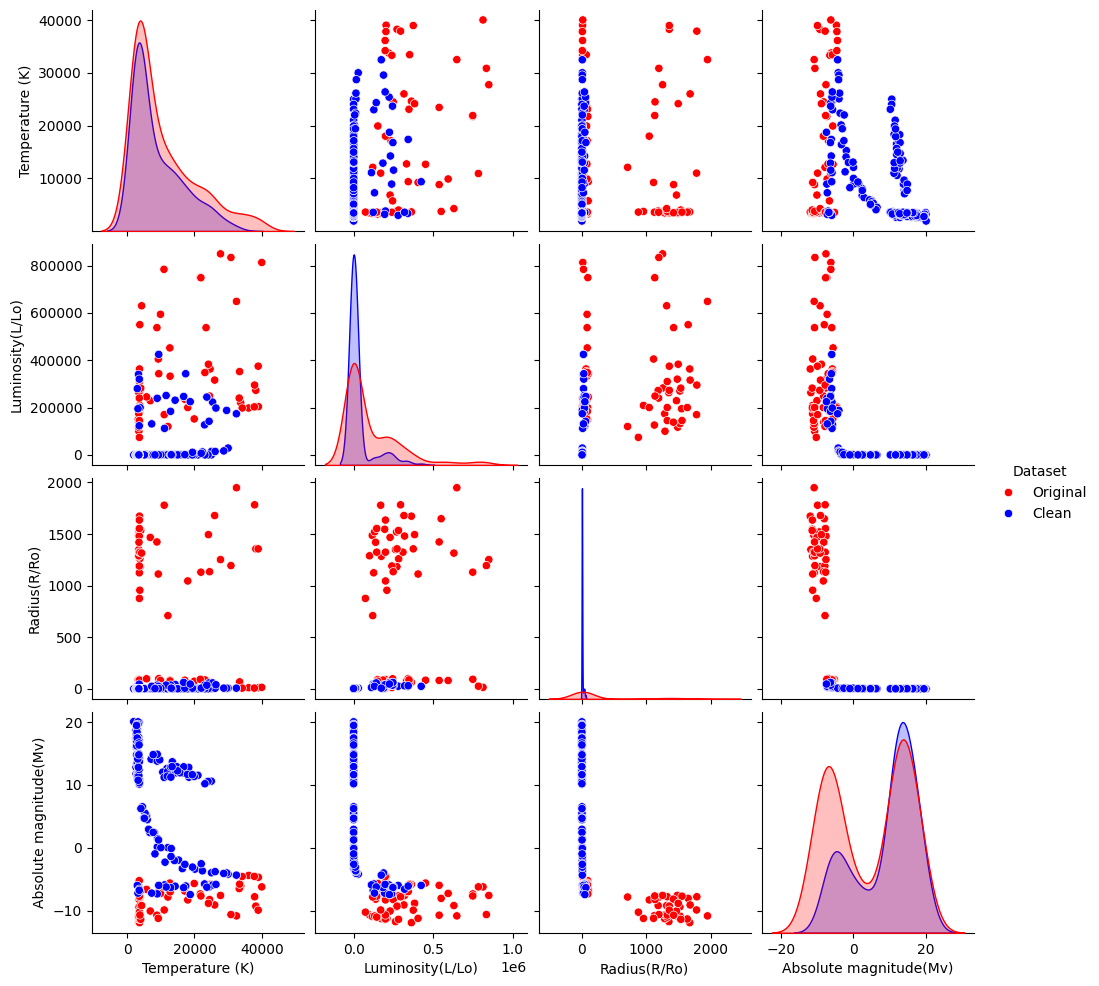

In [ ]:
df['Dataset'] = 'Original'
df_clean['Dataset'] = 'Clean'

df_combined = pd.concat([df, df_clean])

sns.pairplot(
    df_combined.drop(columns='Star type'),
    hue='Dataset',
    palette=['red', 'blue']
)

In [ ]:
df_clean['Star type category'].value_counts()

,count
Star type category,
Brown Dwarf,40
Red Dwarf,40
White Dwarf,40
Main Sequence,36
Supergiant,21


Ahora, eliminamos datos que eran críticos para diferenciar el tipo de estrella 4 "Super Giant", pudiendo dificultar la visualización de los datos, como así también la performance del modelo.
Por esto, es importarte cerciorarse siempre de que los datos que estemos eliminando no sean propios de una de las clases de la variable objetivo.

## ¿Tiene nulos mi dataset? ¿Cómo los trato? ¿Cómo afectó a los datos mi tratamiento?

Una manera sencilla de visualizar si mi dataset tiene nulos es la siguiente:

In [ ]:
df.isna().any().sum()

np.int64(0)

dataset -> es nulo -> cualquier dato de la fila -> sumar

Vemos que el dataset no tiene nulos. Con fines prácticos, introduciremos datos nulos de manera aleatoria en las columnas que no son variable objetivo.

In [ ]:
df_null = df.drop(columns='Dataset').copy()
num_columns = df_null.select_dtypes(include='number').columns
# Número de filas que tendrán 1 null (35%)
n_filas_null = int(len(df_null) * 0.35)

# Seleccionar filas aleatorias sin repetición
filas_seleccionadas = np.random.choice(df_null.index, size=n_filas_null, replace=False)

for fila in filas_seleccionadas:
    # Elegir una columna aleatoria
    col = np.random.choice(num_columns)
    df_null.loc[fila, col] = np.nan


## Agregamos null específicamente en temperatura de Brown Darf
mask = df_null['Star type category'] == 'Brown Dwarf'

filas = df_null[mask].sample(frac=0.5, random_state=42).index

df_null.loc[filas, 'Temperature (K)'] = np.nan

In [ ]:
df_null.isna().sum()

,0
Temperature (K),32
Luminosity(L/Lo),19
Radius(R/Ro),31
Absolute magnitude(Mv),22
Star type,0
Star color,0
Spectral Class,0
Star type category,0


In [ ]:
df_null[df_null.isnull().any(axis=1)]

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class,Star type category
0,NaN,0.002400,0.170,16.12,0,Red,M,Brown Dwarf
4,NaN,0.000138,NaN,20.06,0,Red,M,Brown Dwarf
5,2840.0,NaN,0.110,16.98,0,Red,M,Brown Dwarf
6,NaN,0.000730,0.127,17.22,0,Red,M,Brown Dwarf
8,NaN,0.000690,0.110,17.45,0,Red,M,Brown Dwarf
...,...,...,...,...,...,...,...,...
230,24145.0,382993.000000,NaN,-8.84,5,Blue-white,B,Hypergiant
231,NaN,272830.000000,1356.000,-9.29,5,Blue,O,Hypergiant
233,NaN,849420.000000,1252.000,-7.59,5,Blue-white,B,Hypergiant
237,8829.0,NaN,1423.000,-10.73,5,White,A,Hypergiant


In [ ]:
df_null.isna().any().sum()

np.int64(4)

In [ ]:
df_imputado = df_null.copy()
for col in df_imputado.columns:

    if df_imputado[col].isnull().sum() > 0:

        # Agrupar por TODAS las categóricas excepto la columna actual
        group_cols = [c for c in cat_columns if c != col]

        if len(group_cols) == 0:
            continue

        # Si es numérica → mediana por grupo
        if col in num_columns:
            df_imputado[col] = df_imputado.groupby(group_cols)[col] \
                                           .transform(lambda x: x.fillna(x.median()))

        # Si es categórica → moda por grupo
        elif col in cat_columns:
            df_imputado[col] = df_imputado.groupby(group_cols)[col] \
                                           .transform(lambda x: x.fillna(
                                               x.mode().iloc[0] if not x.mode().empty else np.nan
                                           ))

¿Es correcto llenar una categorica con "Desconocido" u otra palabra?

Veamos que pasa.

- ¿Es "Desconocido" una categoria representada en el fenómeno de estudio?
- ¿De qué me sirve tener una variable con "Desconocido" para el fenómeno de estudio?

Al llenar valores nulos con "Desconocido", estamos introduciendo una categoria nueva en nuestro trabajo. Esto es incorrecto, ya que "Desconocido" no tiene una representación real en el fenómeno de estudio y estaríamos, luego, entrenando un modelo para predecir una categoría inventada por nosotros.
Es lo mismo llenar con "Desconocido" como llenar con "Estrella x", "5", etc.
Esto es un error grave y hay que estar atentos y pensarlo de manera lógica antes de hacerlo.

| Si se quiere que el modelo diga "Desconocido" ante combinaciones de variables no antes vistas, hay otros métodos que se incluyen en la post-predicción del modelo. (Por ej: si la confianza de predicción de un dato para una clase es <%50 , entonces se imprime "No identificado" o "Desconocido").

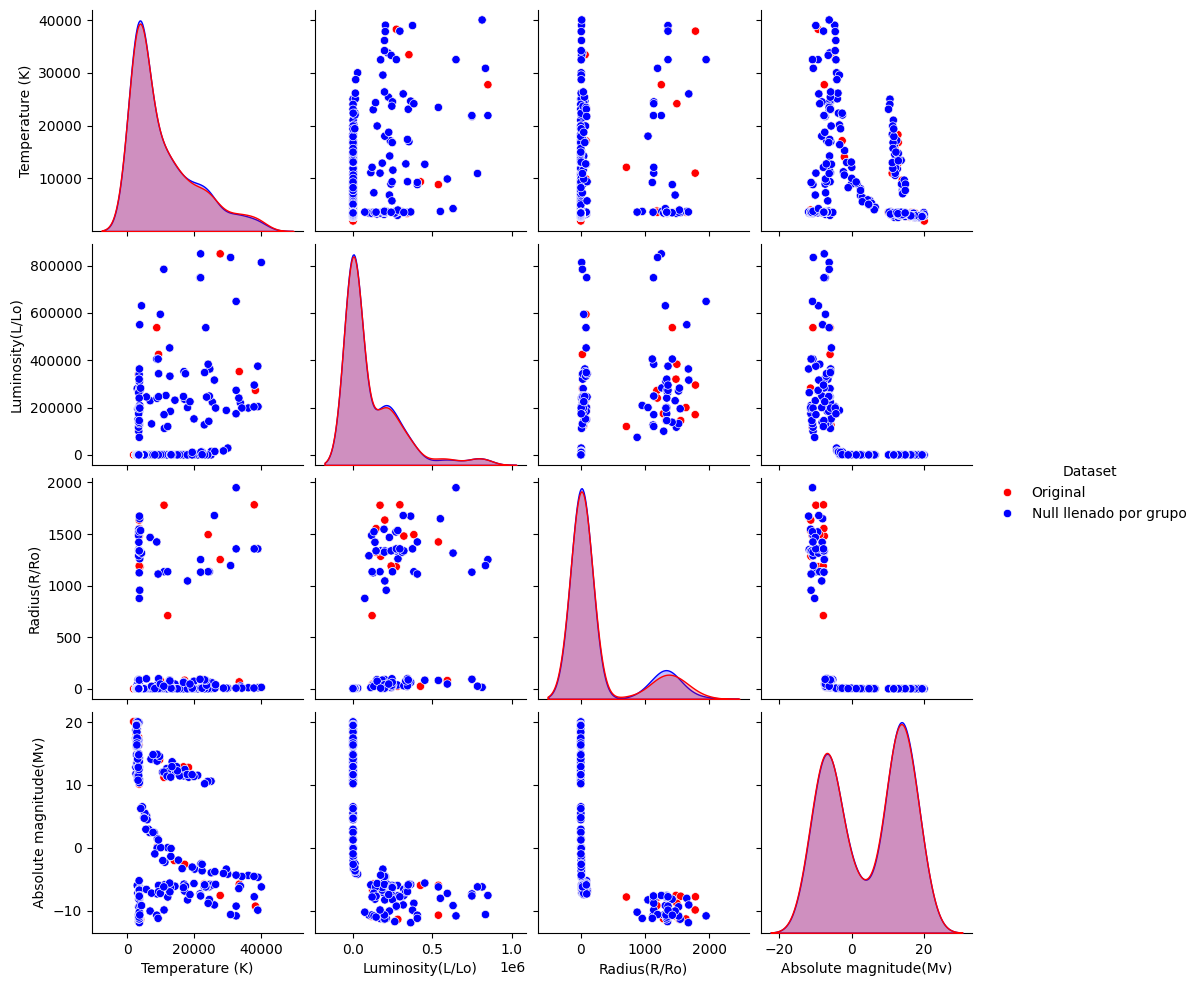

In [ ]:
# Añadir etiqueta identificadora
df_original = df.drop(columns = 'Dataset').copy()
df_original['Dataset'] = 'Original'

df_imputado['Dataset'] = 'Null llenado por grupo'

# Unir datasets
df_combined_null_columna = pd.concat([df_original, df_imputado], ignore_index=True)

# Pairplot
sns.pairplot(
    df_combined_null_columna.drop(columns=['Star type']),
    hue='Dataset',
    palette={'Original': 'red', 'Null llenado por grupo': 'blue'},
    diag_kind='kde'  # se ve mejor para comparar distribuciones
)

plt.show()

<Axes: xlabel='Temperature (K)', ylabel='Count'>

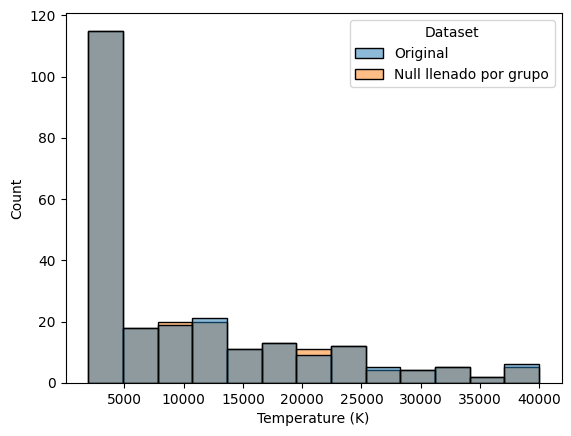

In [ ]:
sns.histplot(
    data=df_combined_null_columna,
    x='Temperature (K)',
    hue='Dataset'
)

¿Si lo llenamos sólo con la mediana, sin importar las otras columnas?

In [ ]:
df_null.isna().any().sum()

np.int64(4)

In [ ]:
df_imputado_2 = df_null.copy()

for col in df_imputado_2.columns:

    # Solo actuar si HAY nulos
    if df_imputado_2[col].isnull().sum() == 0:
        continue

    if col in cat_columns:
        df_imputado_2[col] = df_imputado_2[col].fillna(
            df_imputado_2[col].mode()[0]
        )
    else:
        df_imputado_2[col] = df_imputado_2[col].fillna(
            df_imputado_2[col].median()
        )



In [ ]:
df_original.describe()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv)
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


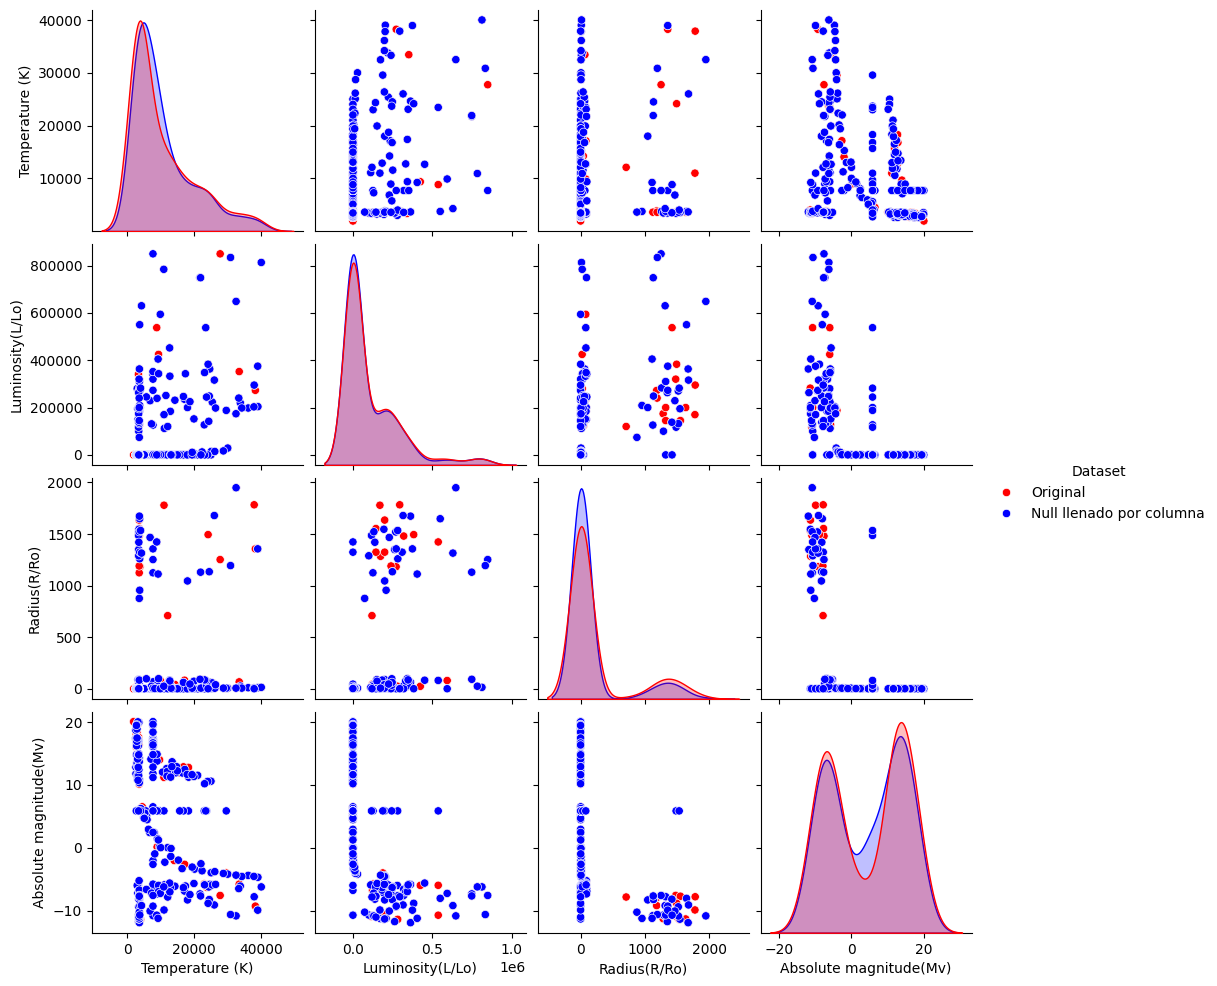

In [ ]:
# Añadir etiqueta identificadora
df_imputado_2['Dataset'] = 'Null llenado por columna'

# Unir datasets
df_combined_null = pd.concat([df_original, df_imputado_2], ignore_index=True)

# Pairplot
sns.pairplot(
    df_combined_null.drop(columns = 'Star type'),
    hue='Dataset',
    palette={'Original': 'red', 'Null llenado por columna': 'blue'},
    diag_kind='kde'  # se ve mejor para comparar distribuciones
)

plt.show()

<Axes: xlabel='Temperature (K)', ylabel='Count'>

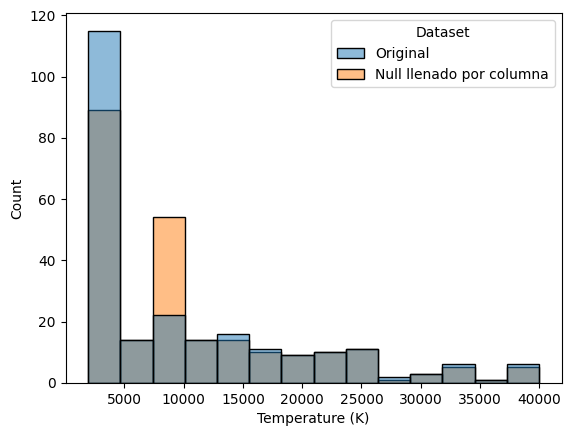

In [ ]:
sns.histplot(
    data=df_combined_null,
    x='Temperature (K)',
    hue='Dataset'
)

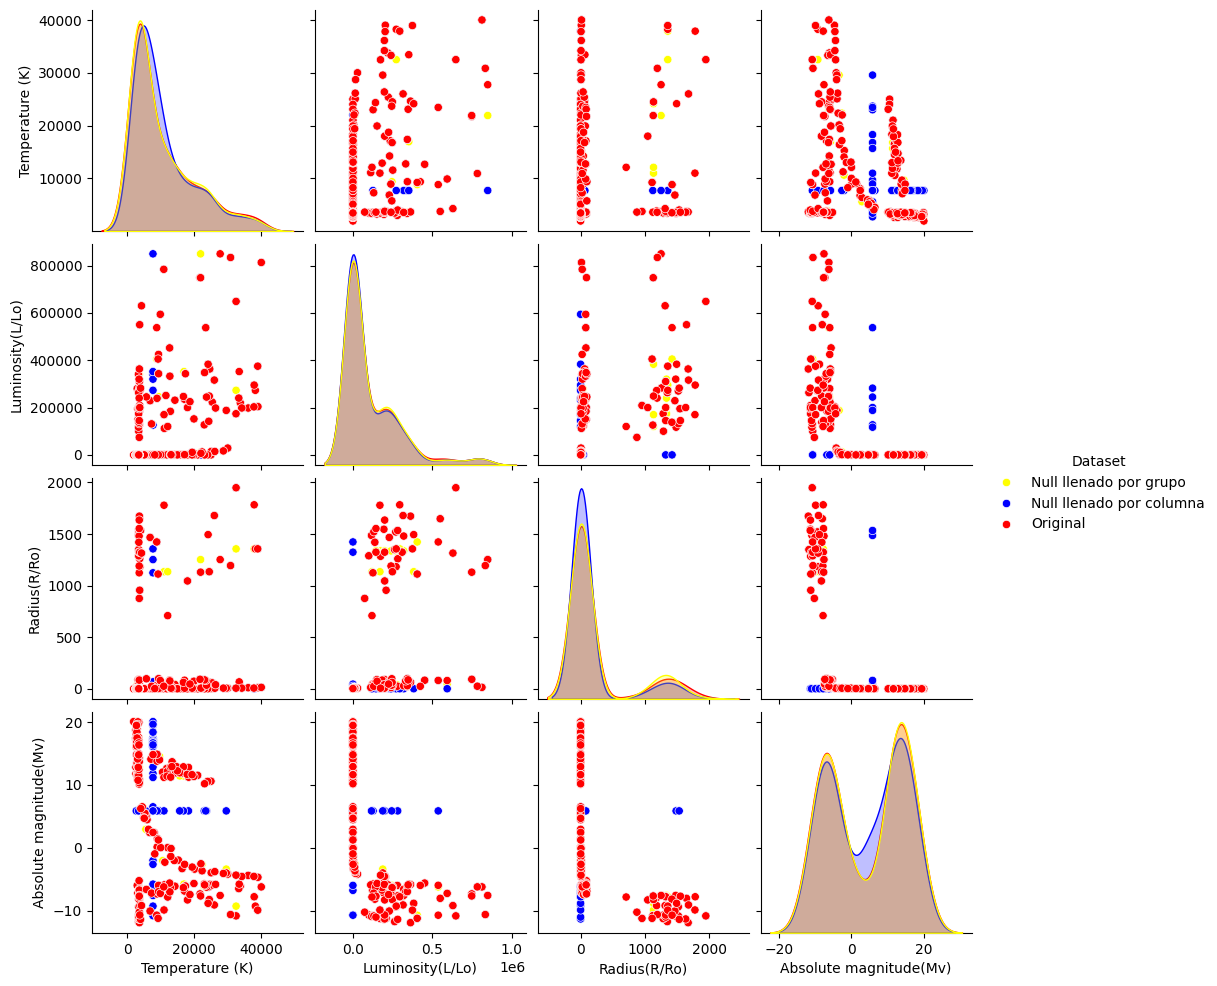

In [ ]:
# Unir datasets
df_combined_null_imputados = pd.concat([df_imputado, df_imputado_2, df_original], ignore_index=True)

# Pairplot
sns.pairplot(
    df_combined_null_imputados.drop(columns = 'Star type'),
    hue='Dataset',
    palette={'Null llenado por grupo': 'yellow', 'Null llenado por columna': 'blue', 'Original': 'red'},
    diag_kind='kde'  # se ve mejor para comparar distribuciones
)

plt.show()

Vemos que, sobretodo en las variables con más discrepancia entre los tipos de estrellas (ej: Temperatura), se nota visiblemente la diferencia entre llenar por grupo similar de filas y directamente por el valor más repetido (moda) o mediana de la columna. El segundo caso, tiende a sesgar los datos con valores que ciertas estrellas nunca toman en los datos.

# PCA



> "PCA es un algoritmo de machine learning no supervisado que intenta reducir la dimensionalidad (número de características) dentro de un conjunto de datos mientras retiene toda la información posible. Esto se realiza buscando un nuevo conjunto de características denominado componentes, que son los compuestos de las características originales que no son correlativas entre sí. También están limitadas, por lo que el primer componente implica la máxima variabilidad posible en los datos y el segundo componente la segunda variabilidad máxima y así sucesivamente." - AWS | [link](https://docs.aws.amazon.com/es_es/sagemaker/latest/dg/pca.html#:~:text=PCA%20es%20un%20algoritmo%20de,utiliza%20un%20algoritmo%20de%20aproximaci%C3%B3n.)

In [ ]:
## Definimos pipeline
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()), #scaler a usar con un output de df
    ('pca', PCA().set_output(transform="pandas")) # algoritmo
])

# Aplicamos el pipeline

df_pca = pca_pipeline.fit_transform(df[num_columns])


In [ ]:
pca_pipeline.named_steps['pca'].explained_variance_ratio_

array([0.60357391, 0.23500784, 0.09329645, 0.0681218 ])

In [ ]:
df_pca

,pca0,pca1,pca2,pca3
0,1.476090,-0.343211,0.157901,0.319705
1,1.503654,-0.343857,0.161887,0.355995
2,1.636288,-0.374996,0.192258,0.506282
3,1.515309,-0.364557,0.171735,0.353587
4,1.735919,-0.427500,0.226676,0.593937
...,...,...,...,...
235,-3.703168,1.177682,-1.237078,1.029830
236,-4.729798,0.667365,1.182107,1.515115
237,-3.211102,-1.489990,0.562704,0.552412
238,-2.553545,-1.117109,0.305920,0.025264


In [ ]:
df_pca[cat_columns] = df[cat_columns]
df_pca['Star type category'] = df['Star type category']

In [ ]:
df_pca.head()

,pca0,pca1,pca2,pca3,Star type,Star color,Spectral Class,Star type category
0,1.476090,-0.343211,0.157901,0.319705,0,Red,M,Brown Dwarf
1,1.503654,-0.343857,0.161887,0.355995,0,Red,M,Brown Dwarf
2,1.636288,-0.374996,0.192258,0.506282,0,Red,M,Brown Dwarf
3,1.515309,-0.364557,0.171735,0.353587,0,Red,M,Brown Dwarf
4,1.735919,-0.427500,0.226676,0.593937,0,Red,M,Brown Dwarf


¿Por qué 4 componentes?

## Criterios de selección de los eigenvalues

**Criterios de selección:**
* Proporción de variancia acumulada (~75% -80%)​
* Criterio de Kaiser (eigenvalues > 1)​
* Gráfico del codo (Scree)

💡 Solo elijo un criterio, no es necesario que se cumplan los tres.

###1. Varianza acumulada

In [ ]:
# Varianza explicada y acumulada
var_exp = pca_pipeline.named_steps['pca'].explained_variance_ratio_
var_cum = np.cumsum(var_exp)
n_comp = len(var_exp)

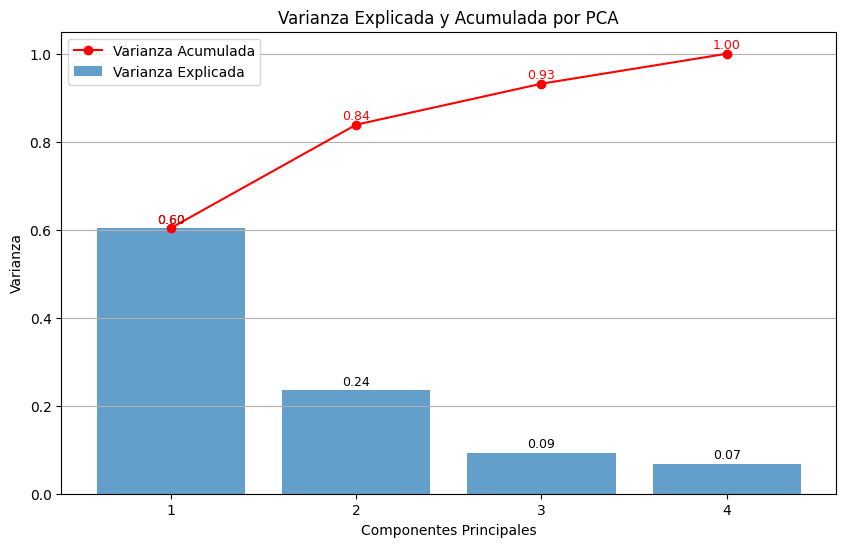

In [ ]:

# Crear figura
fig, ax = plt.subplots(figsize=(10,6))

# Barras: varianza explicada
bars = ax.bar(range(1, n_comp+1), var_exp, alpha=0.7, label='Varianza Explicada')

# Línea: varianza acumulada
line = ax.plot(range(1, n_comp+1), var_cum, color='red', marker='o', label='Varianza Acumulada')

# Etiquetas sobre las barras
for bar, v in zip(bars, var_exp):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

# Etiquetas sobre los puntos de la línea
for i, v in enumerate(var_cum, start=1):
    ax.text(i, v + 0.005, f"{v:.2f}", color='red', ha='center', va='bottom', fontsize=9)

# Etiquetas y estilo
ax.set_xlabel('Componentes Principales')
ax.set_ylabel('Varianza')
ax.set_title('Varianza Explicada y Acumulada por PCA')
ax.set_xticks(range(1, n_comp+1))
ax.legend()
ax.grid(axis='y')

plt.show()

Podemos ver que el criterio de 75%-85% de varianza acumulada con 3 componentes ya se cumple, con 2 sólo le falta un 1%.

La mayor parte de la varianza explicada se acumula en los primeros dos componentes, obteninedo un 60% y 24% respectivamente de la varianza.

### 2. Kaisser

El criterio de Kaisser indica que se deben aceptar los eigenvalues con un valor >= 10% (0.1).

Bajo este criterio, solo las dos primeros cumplen con ese criterio.

In [ ]:
var_exp

array([0.60357391, 0.23500784, 0.09329645, 0.0681218 ])

### 3. Gráfico del codo.

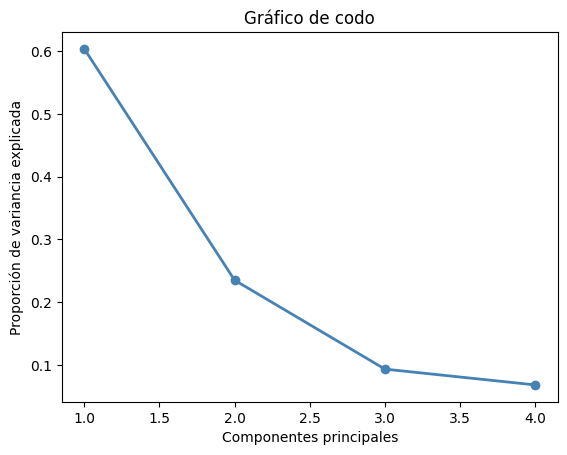

In [ ]:
PC_values = np.arange(pca_pipeline.named_steps['pca'].n_components_) + 1
plt.plot(PC_values, pca_pipeline.named_steps['pca'].explained_variance_ratio_, 'o-', linewidth=2, color='steelblue')
plt.title('Gráfico de codo')
plt.xlabel('Componentes principales')
plt.ylabel('Proporción de variancia explicada')
plt.show()

Según el gráfico del codo, se produce un quiebre entre la segunda y la tercera componente. Considerando que con 2 componentes llegamos a un %84 de varianza acumulada, podemos quedarnos con sólo 2 componentes.

### Conclusión de selección

La única opción que cumple con los 3 criterios de elección es quedarse con las primeras dos componentes. Sin embrago, podemos utilizar la tercera para mejorar la visualización de los datos en caso de ser necesario.

**IMPORTANTE**

**NO** es necesario que se cumplan con los 3 criterios, como lo indica su nombre, son "criterios" por los cuales uno puede regirse a la hora de elegir la cantidad de eigenvalues.
Puedo optar por guiarme por un sólo criterio.

## Visualización de las componentes

### Lo visualizamos en 2D

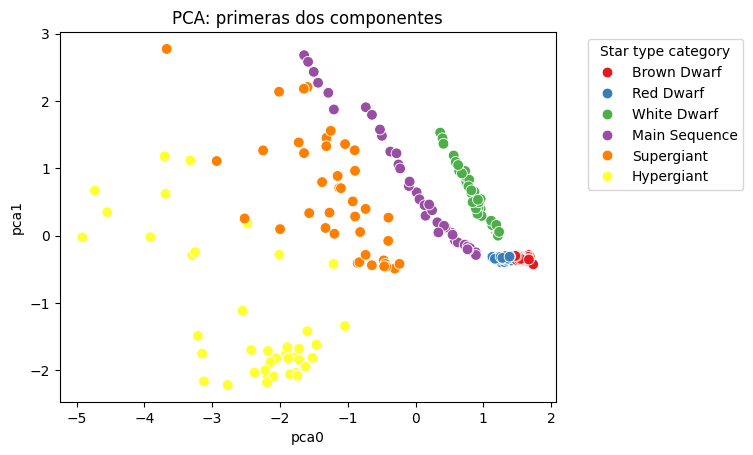

In [ ]:
# Visualizamos en scatterplot las primeras dos componentes
sns.scatterplot(
    x=df_pca['pca0'],
    y=df_pca['pca1'],
    hue=df_pca['Star type category'],
    palette='Set1',
    s=60
)

plt.xlabel('pca0')
plt.ylabel('pca1')
plt.title('PCA: primeras dos componentes')
plt.legend(title='Star type category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Lo visualizamos en 3d

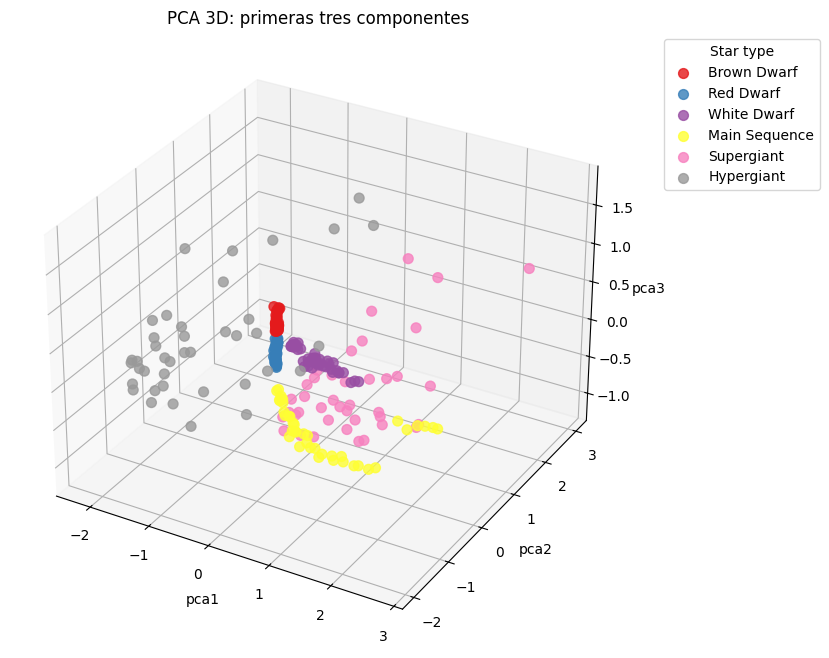

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Crear figura 3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Colores automáticos según categorías
categories = df_pca['Star type category'].unique()
colors = plt.cm.Set1(np.linspace(0, 1, len(categories)))

for cat, color in zip(categories, colors):
    subset = df_pca[df_pca['Star type category'] == cat]
    ax.scatter(subset['pca1'], subset['pca2'], subset['pca3'],
               label=cat, color=color, s=50, alpha=0.8)

ax.set_xlabel('pca1')
ax.set_ylabel('pca2')
ax.set_zlabel('pca3')
ax.set_title('PCA 3D: primeras tres componentes')
ax.legend(title='Star type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Manifold learning
Consiiste en descubrir estructuras de baja dimensionalidad ocultas en estructuras de alta dimensionalidad.

## 🎯 Objetivo
Llevar a la práctica los conceptos de **MDS**, **Isomap**, **t-SNE** y **UMAP**.

## Escalado

In [ ]:
scaler = StandardScaler()
X_std = scaler.fit_transform(df[num_columns])
y = df['Star type category']

## Isomap
**Isometric Mapping** (Isomap) es un método de reducción de dimensionalidad **no lineal** que preserva las distancias geodésicas (caminos más cortos en el grafo de vecinos) para representar los datos en un espacio de menor dimensión, manteniendo su **estructura local y global**.

https://scikit-learn.org/stable/modules/manifold.html#isomap

Tenenbaum, J. B.; De Silva, V.; y Langford, J. C. (2000) *A global geometric framework for nonlinear dimensionality reduction*. Science. http://science.sciencemag.org/content/290/5500/2319.full

In [ ]:
isomap_2D = Isomap(n_neighbors=11, n_components=2).set_output(transform="pandas")
X_2D = isomap_2D.fit_transform(X_std)

In [ ]:
X_2D.shape

(240, 2)

In [ ]:
X_2D['Star type'] = y

### Correlaciones

Deberia ser baja la correlación en los modelos de Manifold Learning?



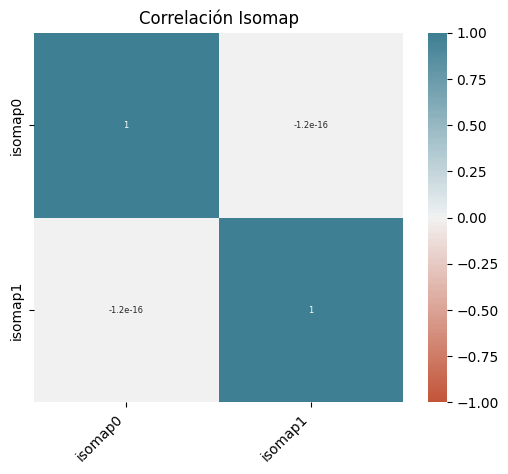

In [ ]:
corr_isomap = X_2D.drop(columns='Star type').corr()
plot_correlation_heatmap(corr_isomap, 'Correlación Isomap')

### Visualización

In [ ]:
# Colores automáticos según categorías
categories = y.unique()
colors = sns.color_palette('Set1', n_colors=len(categories))
colors = colors.as_hex()

In [ ]:
col_names = X_2D.columns
fig_isomap2d = px.scatter(X_2D, x=col_names[0], y=col_names[1],
                           color = 'Star type',
                           labels = {'color':'Star type',
                                     'C1':col_names[0],'C2':col_names[1]},
                           color_discrete_sequence=colors,
                           hover_name='Star type',
                           title='ISOMAP 2D')
fig_isomap2d.show()

In [ ]:
isomap_3D = Isomap(n_neighbors=15, n_components=5).set_output(transform="pandas")
X_3D = isomap_3D.fit_transform(X_std)
X_3D['Star type'] = y

In [ ]:
col_names = X_3D.columns
fig_isomap_3d = px.scatter_3d(X_3D, x=col_names[2], y=col_names[3], z=col_names[4],
                           color = 'Star type',
                           labels = {'color':'Star type',
                                     'C1':col_names[0],'C2':col_names[1],
                                     'C3':col_names[2]},
                           color_discrete_sequence=colors,
                           hover_name='Star type',
                           title='ISOMAP 3D')
fig_isomap_3d.show()

### CONSIGNA - Sección ISOMAP
| Aplica ISOMAP variando los parámetros de la siguiente forma:

- n_neighbors muy alto

- n_neighbors muy bajo y n_components muy alto.

| Realiza un gráfico para cada caso y luego responde:

- ¿Qué cambios observas en la representación?

- ¿Cómo influye n_neighbors en la preservación de la estructura local o global?

- ¿Cuál de los valores de n_neighbors consideras más apropiada para tu dataset y por qué?

## t-SNE
**t-SNE** es una técnica de reducción de dimensionalidad **no lineal** muy útil para datos de alta dimensión. Se basa en el *Embedding de Vecinos Estocástico* (Stochastic Neighborhood Embeddings, SNE), desarrollado por Sam Roweis y Geoffrey Hinton. La variante con distribución t fue propuesta por Lauren van der Maaten. Por lo tanto, t-SNE es una mejora del algoritmo SNE.

https://scikit-learn.org/stable/modules/manifold.html#t-distributed-stochastic-neighbor-embedding-t-sne

https://papers.nips.cc/paper_files/paper/2002/hash/6150ccc6069bea6b5716254057a194ef-Abstract.html

van der Maaten, L.J.P *t-Distributed Stochastic Neighbor Embedding*. https://lvdmaaten.github.io/tsne/

Vaibhav Verdhan (2025) *Data Without Labels*. Manning

In [ ]:
tsne2D = TSNE(n_components=2, init='random', random_state=42,
              method='exact').set_output(transform="pandas")
X_tsne2D = tsne2D.fit_transform(X_std)
print(X_tsne2D.shape)
X_tsne2D['Star type'] = y

(240, 2)


### Correlación

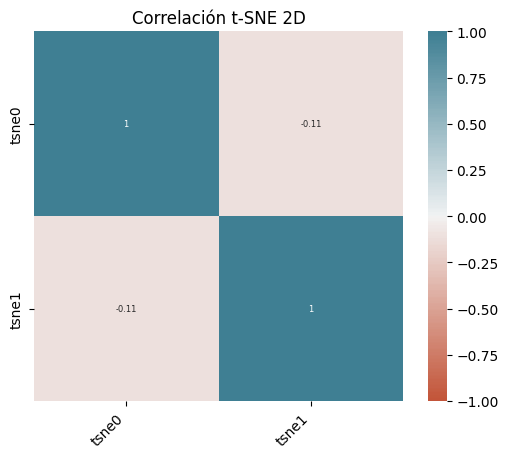

In [ ]:
corr_tsne = X_tsne2D.drop(columns='Star type').corr()
plot_correlation_heatmap(corr_tsne, 'Correlación t-SNE 2D')

### Visualización

In [ ]:
col_names = X_tsne2D.columns
fig_tsne2d = px.scatter(X_tsne2D, x=col_names[0], y=col_names[1],
                           color = 'Star type',
                           labels = {'color':'Star type',
                                     'C1':col_names[0],'C2':col_names[1]},
                           color_discrete_sequence=colors,
                           hover_name='Star type',
                           title='t-SNE 2D')
fig_tsne2d.show()

In [ ]:
tsne3D = TSNE(n_components=3, init='random', random_state=42,
              method='exact').set_output(transform="pandas")
X_tsne3D = tsne3D.fit_transform(X_std)
print(X_tsne3D.shape)
X_tsne3D['Star type'] = y

(240, 3)


In [ ]:
col_names = X_tsne3D.columns
fig_tsne3d = px.scatter_3d(X_tsne3D, x=col_names[0], y=col_names[1],
                           z=col_names[2],
                           color = 'Star type',
                           labels = {'color':'Star type',
                                     'C1':col_names[0],'C2':col_names[1],
                                     'C3':col_names[2]},
                           color_discrete_sequence=colors,
                           hover_name='Star type',
                           title='t-SNE 3D')
fig_tsne3d.show()

### Perplejidad
La perplejidad es un **hiperparámetro** que nos permite controlar y optimizar la **cantidad de vecinos cercanos** que tiene cada punto de datos en t-SNE. Algunos aspectos a tener en cuenta:
- Se recomienda **valores entre 5 y 50**, según el paper original.
- Debe ser **menor al numero de filas** del dataset.
- Mienras **más denso** el dataset **mayor perplejidad**.

### CONSIGNA - Sección T-SNE

| Vuelve a aplicar t-SNE pero elimina la columna 'Temperature (K)' del dataset.

| Compara el resultado con la versión original e interpreta:

- ¿Qué cambios observas en la separación de clústeres?

- ¿A qué se deben estos cambios? Relaciónalos con lo que encontraste en el Análisis Exploratorio (EDA).

| Prueba también variar los parámetros de t-SNE (por ejemplo, **perplexity** o learning_rate) y analiza cómo afectan la representación.

## UMAP
UMAP asume que los datos se encuentran en un **Manifold**. Por lo tanto, intenta proyectar el espacio de alta dimensión en uno de baja dimensión, preservando tanto las relaciones con los vecinos más cercanos, que no son más que la **estructura local**, como las relaciones más amplias, que constituyen la **estructura global**.

Vaibhav Verdhan (2025) *Data Without Labels*. Manning

[Documentación](https://umap-learn.readthedocs.io/en/latest/index.html)

In [ ]:
! pip install umap-learn

In [ ]:
import umap

In [ ]:
umap2d = umap.UMAP(n_components=2, init='random')

In [ ]:
proj_2d = umap2d.fit_transform(X_std)

### Visualización

In [ ]:
fig_umap2d = px.scatter(proj_2d, x=0, y=1,
                           color = y,
                           labels = {'color':'Star type',
                                     0:'C1',1:'C2'},
                           color_discrete_sequence=colors,
                           title='UMAP 2D')
fig_umap2d.show()

In [ ]:
umap3d = umap.UMAP(n_components=3, init='random')
proj_3d = umap3d.fit_transform(X_std)

In [ ]:
fig_umap3d = px.scatter_3d(proj_3d, x=0, y=1, z=2,
                           color = y,
                           labels = {'color':'Star type',
                                     0:'C1',1:'C2', 2:'C3'},
                           color_discrete_sequence=colors,
                           title='UMAP 3D')
fig_umap3d.show()

### CONSIGNA — Sección UMAP

| Prueba UMAP variando los parámetros principales:

- n_neighbors (ej. muy bajo vs. muy alto)

| Haz un plot de cada caso y compara:

- ¿Cómo cambian la compactación y separación de los clústeres?

- ¿Qué valor te parece más adecuada para tu dataset?

- ¿Qué relación encuentras con el análisis exploratorio (EDA) respecto a las variables y a la presencia de atípicos?

| Bonus: compara los resultados de UMAP con los de t-SNE e ISOMAP.

- ¿Qué ventajas o desventajas encontrás en cada método?

## Comparación

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=('ISOMAP 2D', 't-SNE 2D', 'UMAP 2D'))

for trace in fig_isomap2d.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_tsne2d.data:
    fig.add_trace(trace, row=1, col=2)

for trace in fig_umap2d.data:
    fig.add_trace(trace, row=1, col=3)


fig.update_layout(height=400, showlegend=True)

fig.show()